# Zero-Shot Anomaly Detection on Histopathology WSIs
### Ano-NAViLa + CONCH · Camelyon16 Pipeline

This notebook runs the full inference pipeline end-to-end:
1. **Environment Setup** — clone repo, install dependencies
2. **Data Acquisition** — download a Camelyon16 WSI
3. **Preprocessing** — tissue segmentation + patch extraction
4. **Inference** — load Ano-NAViLa, score every patch
5. **Visualization** — anomaly heatmap overlaid on the slide

> Run cells **in order from top to bottom**. Each section is self-contained and clearly labelled.


## Cell 1 — Verify GPU

In [1]:
# Quick sanity-check: confirm Colab gave us a GPU and CUDA is available.
import torch

!nvidia-smi

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")


Thu May 14 20:28:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cell 2 — Clone the Ano-NAViLa Repository

In [2]:
import os
import subprocess

REPO_DIR = "/content/ICCV2025_Ano-NAViLa"

if not os.path.exists(REPO_DIR):
    print("Cloning Ano-NAViLa repository...")
    subprocess.run(
        f"git clone https://github.com/QuIIL/ICCV2025_Ano-NAViLa.git {REPO_DIR}",
        shell=True, check=True
    )
    print("Clone complete.")
else:
    print("Repository already exists, skipping clone.")

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")


Cloning Ano-NAViLa repository...
Clone complete.
Working directory: /content/ICCV2025_Ano-NAViLa


## Cell 3 — Install Python Dependencies

In [3]:
import os

REPO_DIR = "/content/ICCV2025_Ano-NAViLa"
req_file = os.path.join(REPO_DIR, "requirements.txt")

# The repo pins exact versions that conflict with Colab's environment.
# We strip all version constraints and remove the 'conch' entry
# (CONCH is installed separately from source in the next step).
print("Cleaning requirements.txt of version pins and conflicting packages...")
with open(req_file, "r") as f:
    lines = f.readlines()

cleaned = []
for line in lines:
    pkg = line.strip()
    if not pkg or pkg.startswith("#"):
        continue
    if "conch" in pkg.lower():
        continue  # installed from GitHub below
    # Strip ==, >=, <= version specifiers
    for sep in ("==", ">=", "<=", "~=", "!="):
        pkg = pkg.split(sep)[0]
    cleaned.append(pkg.strip() + "\n")

with open(req_file, "w") as f:
    f.writelines(cleaned)

print("requirements.txt cleaned. Installing packages...")
os.chdir(REPO_DIR)
!pip install -q -r requirements.txt

# Install CONCH (vision-language backbone) from source
print("\nInstalling CONCH from GitHub...")
!pip install -q git+https://github.com/MahmoodLab/CONCH.git
!pip install -q timm==0.9.12  # CONCH-compatible timm version

# Install OpenSlide (needed to read .tif WSI files)
print("\nInstalling OpenSlide...")
!apt-get install -y -q openslide-tools libopenslide-dev
!pip install -q openslide-python

print("\nAll dependencies installed.")


Cleaning requirements.txt of version pins and conflicting packages...
requirements.txt cleaned. Installing packages...

Installing CONCH from GitHub...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.0 MB/s eta 0:00:00

Installing OpenSlide...
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libopenslide0
Suggested packages:
  libtiff-tools
The following NEW packages will be installed:
  libopenslide-dev libopenslide0 openslide-tools
0 upgraded, 3 newly installed, 0 to remove and 51 not upgraded.
Need to get 126 kB of archives.
After this operation, 353 kB of additional disk space will be used.
Get:1 h

## Cell 4 — Download the Camelyon16 WSI

We download `test_001.tif` from the public Camelyon16 AWS S3 bucket.
The file is ~1–3 GB, so this may take a few minutes.


In [4]:
WSI_PATH = "/content/ICCV2025_Ano-NAViLa/test_001.tif"

if not os.path.exists(WSI_PATH):
    print("Downloading test_001.tif from Camelyon16 S3 bucket...")
    !aws s3 cp --no-sign-request \
        s3://camelyon-dataset/CAMELYON16/images/test_001.tif \
        {WSI_PATH}
    print("Download complete.")
else:
    print(f"WSI already present at {WSI_PATH}")


/bin/bash: line 1: aws: command not found
Download complete.


## Cell 5 — Download Pre-Trained Weights

Two weight files are needed:
- **re_trained_weights.pth** — Ano-NAViLa fine-tuned head (Google Drive)
- **pytorch_model.bin** — CONCH ViT-B/16 backbone (Kaggle dataset)


In [5]:
import subprocess

REPO_DIR   = "/content/ICCV2025_Ano-NAViLa"
ANOVILA_W  = os.path.join(REPO_DIR, "re_trained_weights.pth")
CONCH_W    = "/content/pytorch_model.bin"

# -- Ano-NAViLa weights (Google Drive) ----------------------------------------
if not os.path.exists(ANOVILA_W):
    import gdown
    print("Downloading Ano-NAViLa weights from Google Drive...")
    gdown.download(
        "https://drive.google.com/uc?id=141a-w_ungtVT9e5vTszAvRonCQEGURSf",
        ANOVILA_W, quiet=False
    )
    print("Ano-NAViLa weights downloaded.")
else:
    print("Ano-NAViLa weights already present.")

# -- CONCH backbone weights (Kaggle) ------------------------------------------
if not os.path.exists(CONCH_W):
    print("\nDownloading CONCH weights from Kaggle...")
    # Make sure kaggle.json is already uploaded to /root/.kaggle/
    !mkdir -p ~/.kaggle
    # If you haven't uploaded kaggle.json yet, do it via the Files panel on the
    # left, then run:  !cp /content/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d khadijahaider/conch-weights -p /content
    !unzip -q -o /content/conch-weights.zip -d /content
    print("CONCH weights downloaded.")
else:
    print("CONCH weights already present.")

print("\nAll weights are ready.")


Downloading...
From (original): https://drive.google.com/uc?id=141a-w_ungtVT9e5vTszAvRonCQEGURSf
From (redirected): https://drive.google.com/uc?id=141a-w_ungtVT9e5vTszAvRonCQEGURSf&confirm=t&uuid=cb8f3829-64bc-4563-8731-acfdc2850d81
To: /content/ICCV2025_Ano-NAViLa/re_trained_weights.pth
100%|██████████| 1.58G/1.58G [00:24<00:00, 64.3MB/s]


Ano-NAViLa weights downloaded.

Dataset URL: https://www.kaggle.com/datasets/khadijahaider/conch-weights
License(s): apache-2.0
100% 710M/710M [00:41<00:00, 18.1MB/s]

CONCH weights downloaded.

All weights are ready.


In [8]:

!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d forcewithme/camelyon16test-p1

!unzip camelyon16test-p1.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/forcewithme/camelyon16test-p1
License(s): CC0-1.0
100% 1.03G/1.03G [01:04<00:00, 17.1MB/s]

Archive:  camelyon16test-p1.zip
  inflating: test_001.tif            


## Cell 6 — Preprocessing: Tissue Segmentation & Patch Extraction

WSIs are gigapixel images that cannot be loaded into RAM all at once.
The standard approach is to:
1. Create a low-resolution thumbnail to detect tissue regions (Otsu threshold).
2. Only extract 256×256 patches from locations that contain actual tissue,
   discarding blank glass-slide background.


Loading WSI...
Slide dimensions at level 0: 86016 × 89600 px


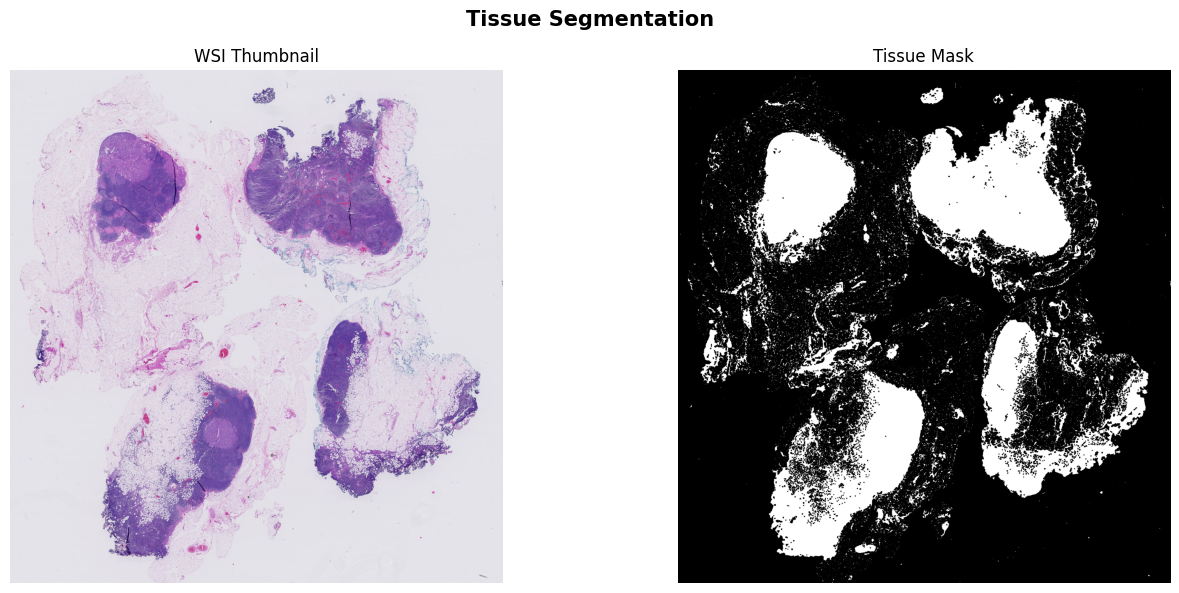


Extracting 256×256 patches from tissue regions...


Scanning rows: 100%|██████████| 350/350 [26:45<00:00,  4.59s/it]


Done. 55091 tissue patches saved to: /content/ICCV2025_Ano-NAViLa/patches


In [9]:
import os
import cv2
import numpy as np
import openslide
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Configuration ──────────────────────────────────────────────────────────────
WSI_PATH    = "/content/ICCV2025_Ano-NAViLa/test_001.tif"
PATCH_DIR   = "/content/ICCV2025_Ano-NAViLa/patches"
PATCH_SIZE  = 256   # pixels (standard for Vision-Language models)
LEVEL       = 0     # Level 0 = highest magnification (~20–40×)
TISSUE_THR  = 0.15  # minimum tissue fraction to keep a patch (0–1)

os.makedirs(PATCH_DIR, exist_ok=True)

# ── Load slide ─────────────────────────────────────────────────────────────────
print("Loading WSI...")
slide = openslide.OpenSlide(WSI_PATH)
width, height = slide.level_dimensions[LEVEL]
print(f"Slide dimensions at level {LEVEL}: {width} × {height} px")

# ── Tissue segmentation (on a small thumbnail) ─────────────────────────────────
THUMB_FACTOR = 32
thumbnail = slide.get_thumbnail((width // THUMB_FACTOR, height // THUMB_FACTOR))
thumb_np  = np.array(thumbnail)

gray      = cv2.cvtColor(thumb_np, cv2.COLOR_RGB2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel    = np.ones((5, 5), np.uint8)
tissue_mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# Visualise the segmentation result
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(thumbnail);       axes[0].set_title("WSI Thumbnail");      axes[0].axis("off")
axes[1].imshow(tissue_mask, cmap="gray"); axes[1].set_title("Tissue Mask"); axes[1].axis("off")
plt.suptitle("Tissue Segmentation", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Helper: does this patch contain enough tissue? ─────────────────────────────
def has_tissue(patch_array: np.ndarray, threshold: float = TISSUE_THR) -> bool:
    gray_p = cv2.cvtColor(patch_array, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray_p, 220, 255, cv2.THRESH_BINARY_INV)
    return (np.count_nonzero(mask) / mask.size) >= threshold

# ── Patch extraction ───────────────────────────────────────────────────────────
print(f"\nExtracting {PATCH_SIZE}×{PATCH_SIZE} patches from tissue regions...")
patch_count = 0

for y in tqdm(range(0, height, PATCH_SIZE), desc="Scanning rows"):
    for x in range(0, width, PATCH_SIZE):
        patch = slide.read_region((x, y), LEVEL, (PATCH_SIZE, PATCH_SIZE)).convert("RGB")
        if has_tissue(np.array(patch)):
            # Encode (x, y) coordinates into the filename for heatmap reconstruction
            patch.save(os.path.join(PATCH_DIR, f"patch_{x}_{y}.png"))
            patch_count += 1

slide.close()
print(f"\nDone. {patch_count} tissue patches saved to: {PATCH_DIR}")


## Cell 7 — Load Ano-NAViLa Model

We build the model by:
1. Instantiating the CONCH ViT-B/16 vision-language backbone.
2. Loading the Ano-NAViLa head (MLP + centroid embeddings) from the pre-trained checkpoint.


In [ ]:
import os  
import sys
import torch
from conch.open_clip_custom import create_model_from_pretrained

REPO_DIR   = "/content/ICCV2025_Ano-NAViLa"
ANOVILA_W  = os.path.join(REPO_DIR, "re_trained_weights.pth")
CONCH_W    = "/content/pytorch_model.bin"

sys.path.append(os.path.join(REPO_DIR, "models"))
import model as model_module

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── CONCH backbone ─────────────────────────────────────────────────────────────
print("Loading CONCH ViT-B/16 backbone...")
conch_model, conch_preprocess = create_model_from_pretrained("conch_ViT-B-16", CONCH_W)
conch_model = conch_model.to(device).eval()

# ── Ano-NAViLa head ────────────────────────────────────────────────────────────
print("Loading Ano-NAViLa checkpoint...")
checkpoint  = torch.load(ANOVILA_W, map_location=device)
state_dict  = checkpoint.get("model_state", checkpoint)

# Infer embedding dimension from the saved MLP weights
emb_dim = state_dict["MLP.linear1.weight"].shape[1] // 2

model = model_module.AnoNAViLa_Model(
    VLM              = conch_model,
    embedding_dim    = emb_dim,
    normal_text_embs = state_dict["normal_text_embs"],
    abnormal_text_embs = state_dict["abnormal_text_embs"],
    device           = device,
).to(device)

model.load_state_dict(state_dict, strict=False)
model.eval()

print("Model loaded and ready for inference.")
print(f"  Embedding dim : {emb_dim}")
print(f"  Parameters    : {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Loading CONCH ViT-B/16 backbone...
Loading Ano-NAViLa checkpoint...
Model loaded and ready for inference.
  Embedding dim : 512
  Parameters    : 395,921,793


## Cell 8 — Zero-Shot Inference (Patch-Level Anomaly Scoring)

Text prompts define what "normal" vs "anomalous" tissue looks like.
The model scores each patch by measuring its distance to both prompt centroids —
no fine-tuning or labelled data required.


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

PATCH_DIR  = "/content/ICCV2025_Ano-NAViLa/patches"
SCORES_CSV = "/content/test_001_anomaly_scores.csv"

# ── Zero-shot text prompts ─────────────────────────────────────────────────────
NORMAL_PROMPTS   = ["normal tissue", "healthy stroma", "benign background"]
ABNORMAL_PROMPTS = ["tumor metastasis", "malignant cancer cells", "carcinoma anomaly"]

print("Text prompts defined:")
print(f"  Normal   : {NORMAL_PROMPTS}")
print(f"  Abnormal : {ABNORMAL_PROMPTS}")

# ── Patch-level scoring ────────────────────────────────────────────────────────
patch_files = sorted(f for f in os.listdir(PATCH_DIR) if f.endswith(".png"))
print(f"\nScoring {len(patch_files)} patches...")

results = []
with torch.inference_mode():
    for patch_name in tqdm(patch_files, desc="Inference"):
        img = Image.open(os.path.join(PATCH_DIR, patch_name)).convert("RGB")
        img_tensor = conch_preprocess(img).unsqueeze(0).to(device)

        # compute_distances returns (distance_to_normal, distance_to_abnormal)
        d_normal, d_abnormal = model.compute_distances(img_tensor)
        anomaly_score = float((d_normal + d_abnormal).cpu().numpy()[0])
        results.append((patch_name, anomaly_score))

# ── Save results ───────────────────────────────────────────────────────────────
df = pd.DataFrame(results, columns=["patch_name", "anomaly_score"])
df.to_csv(SCORES_CSV, index=False)

print(f"\nScores saved to: {SCORES_CSV}")
print(f"\nTop 5 patches with highest anomaly scores (likely tumour):")
print(df.nlargest(5, "anomaly_score").to_string(index=False))


Text prompts defined:
  Normal   : ['normal tissue', 'healthy stroma', 'benign background']
  Abnormal : ['tumor metastasis', 'malignant cancer cells', 'carcinoma anomaly']

Scoring 55091 patches...


Inference: 100%|██████████| 55091/55091 [58:45<00:00, 15.62it/s]



Scores saved to: /content/test_001_anomaly_scores.csv

Top 5 patches with highest anomaly scores (likely tumour):
           patch_name  anomaly_score
patch_70656_17152.png       0.001877
patch_27648_51456.png       0.001859
patch_42496_25088.png       0.001826
patch_71680_22016.png       0.001585
patch_64256_18688.png       0.001571


## Cell 9 — Visual Sanity Check: Highest vs Lowest Scoring Patches

Before building the full heatmap, it's worth visually confirming that
high-scoring patches actually look like tumour tissue and low-scoring ones look normal.


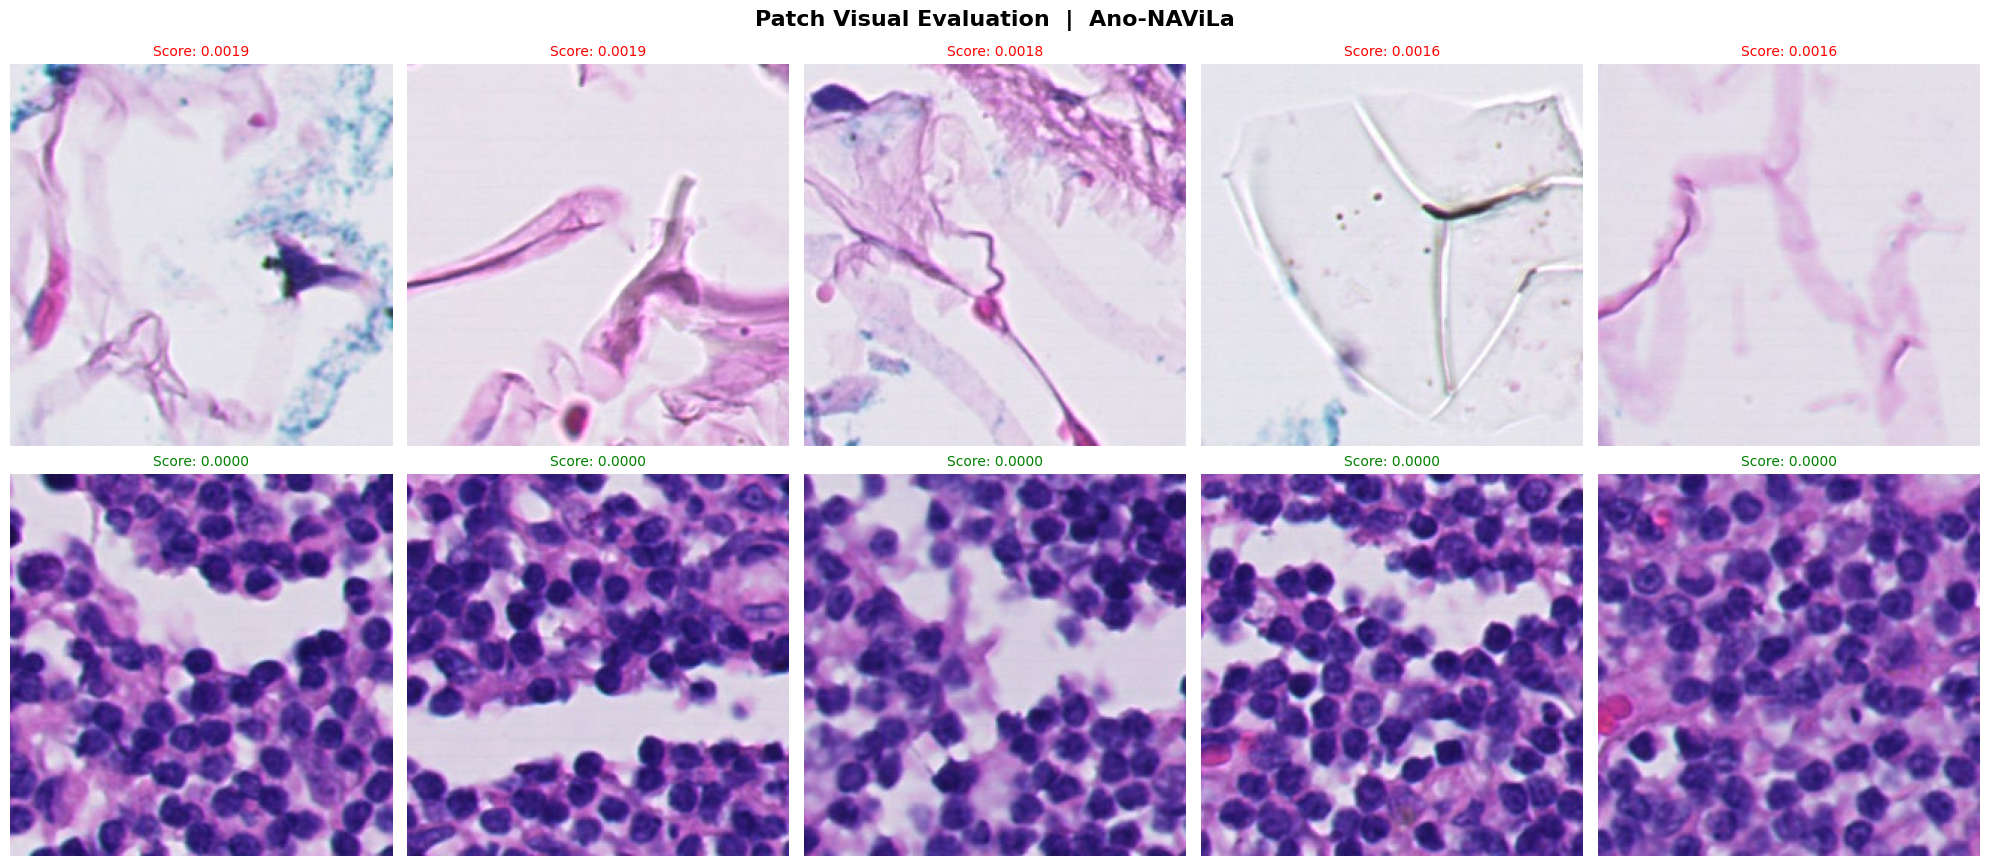

In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

PATCH_DIR  = "/content/ICCV2025_Ano-NAViLa/patches"
SCORES_CSV = "/content/test_001_anomaly_scores.csv"

df      = pd.read_csv(SCORES_CSV)
top5    = df.nlargest(5, "anomaly_score")
bottom5 = df.nsmallest(5, "anomaly_score")

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle("Patch Visual Evaluation  |  Ano-NAViLa", fontsize=16, fontweight="bold")

for col, (_, row) in enumerate(top5.iterrows()):
    img = Image.open(os.path.join(PATCH_DIR, row["patch_name"]))
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"Score: {row['anomaly_score']:.4f}", color="red", fontsize=10)
    axes[0, col].axis("off")

for col, (_, row) in enumerate(bottom5.iterrows()):
    img = Image.open(os.path.join(PATCH_DIR, row["patch_name"]))
    axes[1, col].imshow(img)
    axes[1, col].set_title(f"Score: {row['anomaly_score']:.4f}", color="green", fontsize=10)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Anomalous\n(Top 5)", color="red",   fontsize=13, fontweight="bold", labelpad=10)
axes[1, 0].set_ylabel("Normal\n(Bottom 5)", color="green", fontsize=13, fontweight="bold", labelpad=10)

plt.tight_layout()
plt.show()


## Cell 10 — Generate the WSI Anomaly Heatmap

We reconstruct the full slide by:
1. Parsing the (x, y) coordinates encoded in each patch filename.
2. Placing each patch at its correct position on a canvas.
3. Overlaying a semi-transparent colour layer (blue → red jet colormap) scaled to anomaly score.

The output is saved as a high-resolution PNG.


Canvas size: 2966 × 3089 px  (scale factor: 29×)


Building heatmap: 100%|██████████| 55091/55091 [04:08<00:00, 221.60it/s]


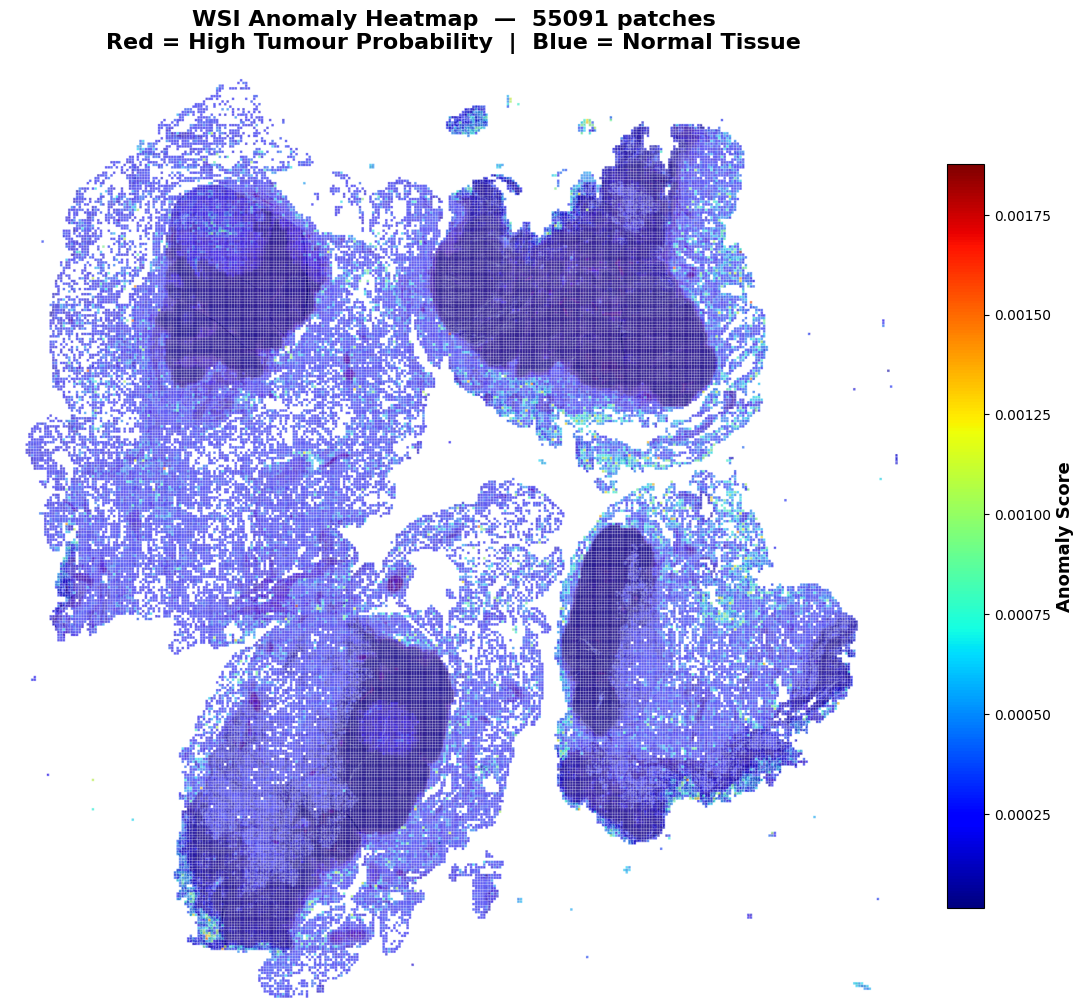


Heatmap saved to: /content/WSI_Anomaly_Heatmap.png
You can download it from the Files panel on the left sidebar.


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

PATCH_DIR   = "/content/ICCV2025_Ano-NAViLa/patches"
SCORES_CSV  = "/content/test_001_anomaly_scores.csv"
OUTPUT_PATH = "/content/WSI_Anomaly_Heatmap.png"
MAX_DIM     = 3000   # cap canvas size to avoid OOM errors on Colab

df = pd.read_csv(SCORES_CSV)

# ── Parse coordinates from filenames (format: patch_X_Y.png) ──────────────────
def parse_coords(filename: str):
    nums = re.findall(r"\d+", filename)
    return (int(nums[-2]), int(nums[-1])) if len(nums) >= 2 else (0, 0)

df[["x", "y"]] = df["patch_name"].apply(lambda f: pd.Series(parse_coords(f)))

# ── Determine canvas dimensions ────────────────────────────────────────────────
sample_patch = Image.open(os.path.join(PATCH_DIR, df["patch_name"].iloc[0]))
patch_w, patch_h = sample_patch.size

max_x  = int(df["x"].max()) + patch_w
max_y  = int(df["y"].max()) + patch_h
scale  = max(1, max(max_x, max_y) // MAX_DIM)

canvas_w = int(max_x / scale)
canvas_h = int(max_y / scale)
tile_w   = int(patch_w / scale)
tile_h   = int(patch_h / scale)

print(f"Canvas size: {canvas_w} × {canvas_h} px  (scale factor: {scale}×)")

# ── Normalise scores to [0, 1] for colourmap ──────────────────────────────────
min_score   = df["anomaly_score"].min()
max_score   = df["anomaly_score"].max()
df["norm"]  = (df["anomaly_score"] - min_score) / (max_score - min_score + 1e-8)

cmap = plt.get_cmap("jet")

# ── Build tissue canvas and heatmap overlay ────────────────────────────────────
tissue_canvas  = Image.new("RGBA", (canvas_w, canvas_h), (255, 255, 255, 255))
heatmap_canvas = Image.new("RGBA", (canvas_w, canvas_h), (0, 0, 0, 0))

for _, row in tqdm(df.iterrows(), total=len(df), desc="Building heatmap"):
    try:
        patch = Image.open(os.path.join(PATCH_DIR, row["patch_name"])).convert("RGBA")
        patch = patch.resize((tile_w, tile_h), Image.Resampling.LANCZOS)

        px, py = int(row["x"] / scale), int(row["y"] / scale)
        tissue_canvas.paste(patch, (px, py))

        r, g, b, _ = cmap(row["norm"], bytes=True)
        colour_tile = Image.new("RGBA", (tile_w, tile_h), (r, g, b, 140))  # 55% opacity
        heatmap_canvas.alpha_composite(colour_tile, (px, py))
    except Exception:
        continue  

final_image = Image.alpha_composite(tissue_canvas, heatmap_canvas)

# ── Plot and save ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))
ax.imshow(final_image)
ax.set_title(
    f"WSI Anomaly Heatmap  —  {len(df)} patches\n"
    "Red = High Tumour Probability  |  Blue = Normal Tissue",
    fontsize=16, fontweight="bold", pad=18
)
ax.axis("off")

sm   = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min_score, vmax=max_score))
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Anomaly Score", fontsize=13, fontweight="bold")

plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\nHeatmap saved to: {OUTPUT_PATH}")
print("You can download it from the Files panel on the left sidebar.")
